In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import rioxarray
import xcdat as xc
import pyet
import os

In [85]:
P_grid = xr.open_dataset("Data/Rijn_up_prec.nc")

T_grid = xr.open_dataset("Data/Rijn_up_temp.nc")

T_grid = T_grid.assign_coords(
    longitude=P_grid.longitude,
    latitude=P_grid.latitude,
)

ds = xr.Dataset({
    "P": P_grid["rr"],
    "T": T_grid["tg"],
})


In [102]:
P_grid.info

<bound method Dataset.info of <xarray.Dataset> Size: 274MB
Dimensions:         (time: 27394, latitude: 43, longitude: 58, bnds: 2)
Coordinates:
  * time            (time) datetime64[ns] 219kB 1950-01-01 ... 2024-12-31
  * latitude        (latitude) float64 344B 46.35 46.45 46.55 ... 50.45 50.55
  * longitude       (longitude) float64 464B 6.15 6.25 6.35 ... 11.75 11.85
Dimensions without coordinates: bnds
Data variables:
    spatial_ref     int64 8B ...
    rr              (time, latitude, longitude) float32 273MB ...
    longitude_bnds  (longitude, bnds) float64 928B ...
    latitude_bnds   (latitude, bnds) float64 688B ...
Attributes:
    CDI:            Climate Data Interface version 2.4.4 (https://mpimet.mpg....
    Conventions:    CF-1.4
    E-OBS_version:  31.0e
    References:     http://surfobs.climate.copernicus.eu/dataaccess/access_eo...
    history:        Mon Mar  3 14:06:02 2025: ncks --no-abc -d time,0,27393 /...
    CDO:            Climate Data Operators version 2.4.4 (h

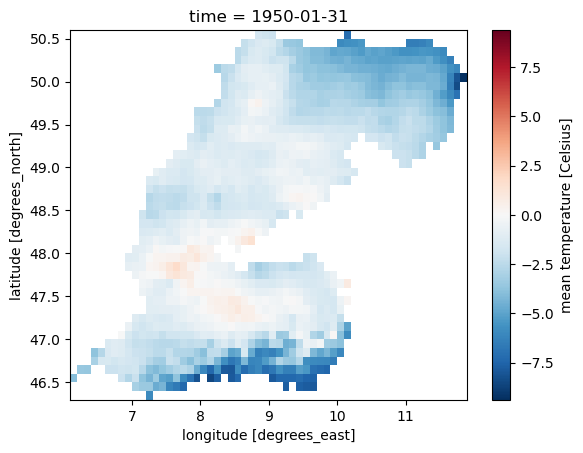

In [86]:
example = ds.isel(time=30)
example["T"].plot()

In [101]:
ds["T"].coords["latitude"]

<xarray.DataArray 'latitude' (latitude: 43)> Size: 344B
array([46.34986, 46.44986, 46.54986, 46.64986, 46.74986, 46.84986, 46.94986,
       47.04986, 47.14986, 47.24986, 47.34986, 47.44986, 47.54986, 47.64986,
       47.74986, 47.84986, 47.94986, 48.04986, 48.14986, 48.24986, 48.34986,
       48.44986, 48.54986, 48.64986, 48.74986, 48.84986, 48.94986, 49.04986,
       49.14986, 49.24986, 49.34986, 49.44986, 49.54986, 49.64986, 49.74986,
       49.84986, 49.94986, 50.04986, 50.14986, 50.24986, 50.34986, 50.44986,
       50.54986])
Coordinates:
  * latitude  (latitude) float64 344B 46.35 46.45 46.55 ... 50.35 50.45 50.55
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
    bounds:         latitude_bnds

In [88]:
spatial_template = ds["T"].isel(time=0, drop=True)  # dims: latitude, longitude (no time)
lat_full, _ = xr.broadcast(ds["T"].latitude, spatial_template)

ds["PET"] = pyet.blaney_criddle(tmean=ds["T"], lat=lat_full)

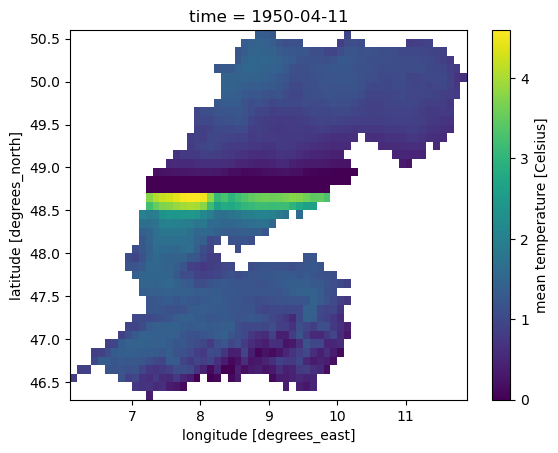

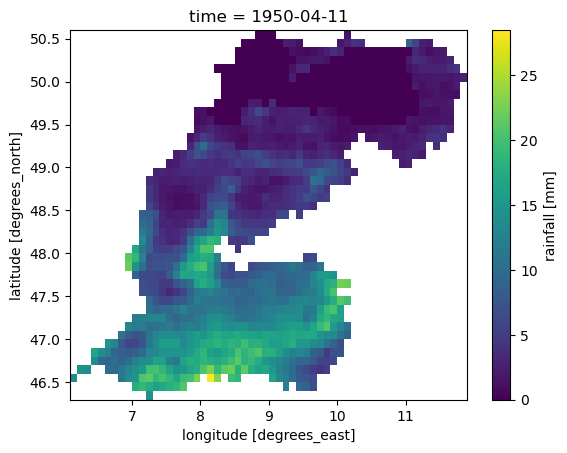

In [89]:
example = ds.isel(time=100)
example["PET"].plot()
plt.figure()
# example = ds.isel(time=30)
example["P"].plot()

In [4]:
def moisturecalculator2000_grid(PET, P, T, Su_max=125):
    """
    Vectorized version of snowcalculator2000, applied to full grids at once.
    
    P, T : np.ndarray, shape (time, lat, lon)
    
    Returns
    -------
    M : np.ndarray, shape (time, lat, lon) — snowmelt
    """
    n_time, n_lat, n_lon = P.shape

    Su  = np.zeros((n_time, n_lat, n_lon), dtype=np.float32)
    dSu = np.zeros_like(Su)
    Q  = np.zeros_like(Su)
    E   = np.zeros_like(Su)

    Su[-1] = 125

    for i in range(n_time):

        # previous day's storage (day -1 wraps to zeros array, same as original)
        Su_prev = Su[i - 1]  # i=0 -> Su[-1], which is still all zeros at this point

        # Evapotranspiration estimate, capped by previous storage
        E[i] = np.minimum(0.75 * PET[i], Su_prev)
        Q[i] = P[i] - (Su_max-Su_prev)

        # update storage
        dSu[i] = P[i] - E[i] - np.maximum(Q[i],0)
        Su[i] = Su_prev + dSu[i]

        # if i%100 == 0:
        #     print(f"ProgreSu: {100*i/n_time}%")
        
    return Q, E, Su

In [5]:
def snowcalculator2000_grid(P, T, f=10, Tcrit=2):
    """
    Vectorized version of snowcalculator2000, applied to full grids at once.
    
    P, T : np.ndarray, shape (time, lat, lon)
    
    Returns
    -------
    M : np.ndarray, shape (time, lat, lon) — snowmelt
    """
    n_time, n_lat, n_lon = P.shape

    Ss  = np.zeros((n_time, n_lat, n_lon), dtype=np.float32)
    dSs = np.zeros_like(Ss)
    Ps  = np.zeros_like(Ss)
    M   = np.zeros_like(Ss)

    for i in range(n_time):
        # snowfall: precip counts as snow where T < Tcrit
        Ps[i] = np.where(T[i] < Tcrit, P[i], 0.0)

        # previous day's storage (day -1 wraps to zeros array, same as original)
        Ss_prev = Ss[i - 1]  # i=0 -> Ss[-1], which is still all zeros at this point

        # melt estimate, capped by previous storage
        M[i] = np.minimum(f * np.maximum(T[i] - Tcrit, 0.0), Ss_prev)

        # update storage
        dSs[i] = Ps[i] - M[i]
        Ss[i] = Ss_prev + dSs[i]

        # if i%100 == 0:
        #     print(f"Progress: {100*i/n_time}%")
        
    return M,Ps,Ss

In [92]:

P_vals = ds["P"].values.astype(np.float32)  # (time, lat, lon)
T_vals = ds["T"].values.astype(np.float32)
PET_vals = ds["PET"].values.astype(np.float32)

M_vals, Ps_vals, Sstorage_vals= snowcalculator2000_grid(P_vals, T_vals)

ds["M"] = (("time", "latitude", "longitude"), M_vals)
ds["Ps"] = (("time", "latitude", "longitude"), Ps_vals)
ds["Ss"] = (("time", "latitude", "longitude"), Sstorage_vals)

ds["P"] = (("time", "latitude", "longitude"), P_vals-Ps_vals)
# # carry over grid metadata
ds["longitude_bnds"] = P_grid["longitude_bnds"]
ds["latitude_bnds"] = P_grid["latitude_bnds"]
ds["spatial_ref"] = P_grid["spatial_ref"]


Progress: 0.0%
Progress: 0.3650434401693802%
Progress: 0.7300868803387603%
Progress: 1.0951303205081404%
Progress: 1.4601737606775207%
Progress: 1.8252172008469008%
Progress: 2.190260641016281%
Progress: 2.555304081185661%
Progress: 2.9203475213550414%
Progress: 3.2853909615244214%
Progress: 3.6504344016938015%
Progress: 4.015477841863182%
Progress: 4.380521282032562%
Progress: 4.745564722201942%
Progress: 5.110608162371322%
Progress: 5.475651602540703%
Progress: 5.840695042710083%
Progress: 6.205738482879463%
Progress: 6.570781923048843%
Progress: 6.935825363218223%
Progress: 7.300868803387603%
Progress: 7.665912243556983%
Progress: 8.030955683726363%
Progress: 8.395999123895743%
Progress: 8.761042564065123%
Progress: 9.126086004234503%
Progress: 9.491129444403883%
Progress: 9.856172884573263%
Progress: 10.221216324742644%
Progress: 10.586259764912025%
Progress: 10.951303205081405%
Progress: 11.316346645250785%
Progress: 11.681390085420166%
Progress: 12.046433525589546%
Progress: 12.4

In [93]:
Q, E, Su= moisturecalculator2000_grid(PET_vals, P_vals, T_vals)

ds["Q"] = (("time", "latitude", "longitude"), Q)
ds["E"] = (("time", "latitude", "longitude"), E)
ds["Su"] = (("time", "latitude", "longitude"), Su)

# ds["P"] = (("time", "latitude", "longitude"), P_vals-Ps_vals)
# # carry over grid metadata
ds["longitude_bnds"] = P_grid["longitude_bnds"]
ds["latitude_bnds"] = P_grid["latitude_bnds"]
ds["spatial_ref"] = P_grid["spatial_ref"]

ProgreSu: 0.0%
ProgreSu: 0.3650434401693802%
ProgreSu: 0.7300868803387603%
ProgreSu: 1.0951303205081404%
ProgreSu: 1.4601737606775207%
ProgreSu: 1.8252172008469008%
ProgreSu: 2.190260641016281%
ProgreSu: 2.555304081185661%
ProgreSu: 2.9203475213550414%
ProgreSu: 3.2853909615244214%
ProgreSu: 3.6504344016938015%
ProgreSu: 4.015477841863182%
ProgreSu: 4.380521282032562%
ProgreSu: 4.745564722201942%
ProgreSu: 5.110608162371322%
ProgreSu: 5.475651602540703%
ProgreSu: 5.840695042710083%
ProgreSu: 6.205738482879463%
ProgreSu: 6.570781923048843%
ProgreSu: 6.935825363218223%
ProgreSu: 7.300868803387603%
ProgreSu: 7.665912243556983%
ProgreSu: 8.030955683726363%
ProgreSu: 8.395999123895743%
ProgreSu: 8.761042564065123%
ProgreSu: 9.126086004234503%
ProgreSu: 9.491129444403883%
ProgreSu: 9.856172884573263%
ProgreSu: 10.221216324742644%
ProgreSu: 10.586259764912025%
ProgreSu: 10.951303205081405%
ProgreSu: 11.316346645250785%
ProgreSu: 11.681390085420166%
ProgreSu: 12.046433525589546%
ProgreSu: 12.4

<Figure size 640x480 with 0 Axes>

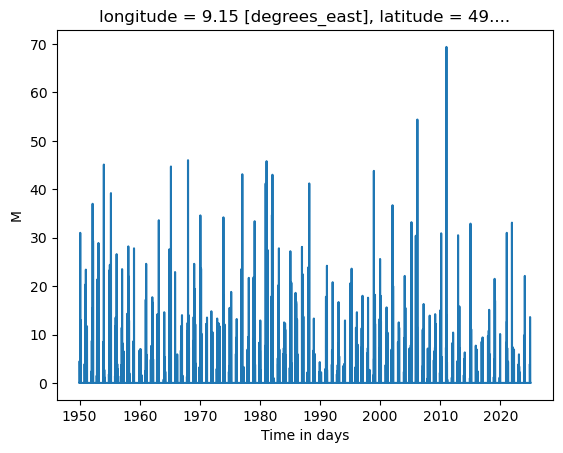

<Figure size 640x480 with 0 Axes>

In [99]:
example = ds.isel(latitude=30, longitude=30)
# example["Q"].plot()
# example["P"].plot()
example["M"].plot()
# plt.xlim((4500,5300))
plt.figure()
# example = ds.isel(time=30)
# example["E"].plot()

In [95]:
ds.to_netcdf("Data/EVERYTHING.nc")

In [96]:
ds_sum = ds.sum(dim=("latitude", "longitude"), skipna=True, keep_attrs=False)
ds_sum = ds_sum.drop_dims("bnds")

(4100, 5000)

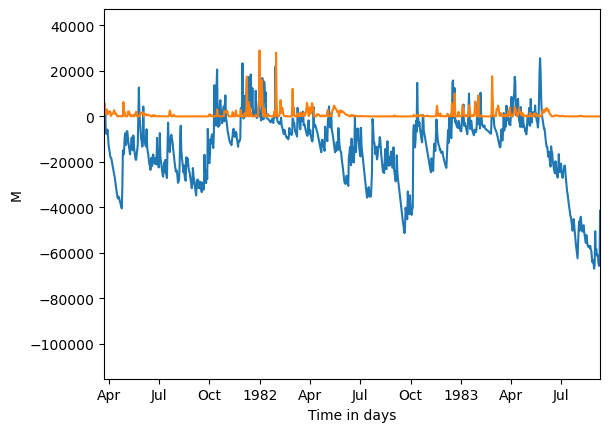

In [97]:
ds_sum["Q"].plot()
ds_sum["M"].plot()
plt.xlim((4100,5000))

In [98]:
df_sum = ds_sum.to_dataframe()
df_sum.to_pickle("Data/MoistPickle.pkl")

In [6]:
def import_Q(dataloc, storeloc):
    df = pd.read_csv(
    dataloc,
    sep=";",
    skipinitialspace=True,
    na_values=["-999.000", "-999"],
    skiprows=36,
    encoding="latin-1"
    )
    df.describe()
    Q = df.drop(columns=df.columns[1])
    Q.columns = ["Date", "Q"]
    Q["Date"] = pd.to_datetime(Q["Date"])
    # plt.plot(Q["Date"], Q["Q"])
    # Q_X = Q.to_xarray()
    # Q_X.to_netcdf(storeloc, mode='w')
    # Q_P = Q_P.set_index()
    return Q

In [7]:
def SuperProgram(loc):
    ds = xr.open_dataset(loc)

    spatial_template = ds["T"].isel(time=0, drop=True)  # dims: latitude, longitude (no time)
    lat_full, _ = xr.broadcast(ds["T"].latitude, spatial_template)

    ds["PET"] = pyet.blaney_criddle(tmean=ds["T"], lat=lat_full)

    P_vals = ds["P"].values.astype(np.float32)  # (time, lat, lon)
    T_vals = ds["T"].values.astype(np.float32)
    PET_vals = ds["PET"].values.astype(np.float32)

    M_vals, Ps_vals, Sstorage_vals= snowcalculator2000_grid(P_vals, T_vals)

    ds["M"] = (("time", "latitude", "longitude"), M_vals)
    # ds["Ps"] = (("time", "latitude", "longitude"), Ps_vals)
    # ds["Ss"] = (("time", "latitude", "longitude"), Sstorage_vals)

    ds["P"] = (("time", "latitude", "longitude"), P_vals-Ps_vals)

    Q, E, Su= moisturecalculator2000_grid(PET_vals, P_vals, T_vals)

    ds["R"] = (("time", "latitude", "longitude"), Q)
    # ds["E"] = (("time", "latitude", "longitude"), E)
    # ds["Su"] = (("time", "latitude", "longitude"), Su)

    # # carry over grid metadata
    # ds["longitude_bnds"] = P_grid["longitude_bnds"]
    # ds["latitude_bnds"] = P_grid["latitude_bnds"]
    # ds["spatial_ref"] = P_grid["spatial_ref"]

    ds_sum = ds.mean(dim=("latitude", "longitude"), skipna=True, keep_attrs=False)
    # ds_sum = ds_sum.drop_dims("bnds")

    return ds_sum

In [34]:
data = SuperProgram("Data/testcomb.nc")

Progress: 0.0%
Progress: 0.3650434401693802%
Progress: 0.7300868803387603%
Progress: 1.0951303205081404%
Progress: 1.4601737606775207%
Progress: 1.8252172008469008%
Progress: 2.190260641016281%
Progress: 2.555304081185661%
Progress: 2.9203475213550414%
Progress: 3.2853909615244214%
Progress: 3.6504344016938015%
Progress: 4.015477841863182%
Progress: 4.380521282032562%
Progress: 4.745564722201942%
Progress: 5.110608162371322%
Progress: 5.475651602540703%
Progress: 5.840695042710083%
Progress: 6.205738482879463%
Progress: 6.570781923048843%
Progress: 6.935825363218223%
Progress: 7.300868803387603%
Progress: 7.665912243556983%
Progress: 8.030955683726363%
Progress: 8.395999123895743%
Progress: 8.761042564065123%
Progress: 9.126086004234503%
Progress: 9.491129444403883%
Progress: 9.856172884573263%
Progress: 10.221216324742644%
Progress: 10.586259764912025%
Progress: 10.951303205081405%
Progress: 11.316346645250785%
Progress: 11.681390085420166%
Progress: 12.046433525589546%
Progress: 12.4

(4700, 4900)

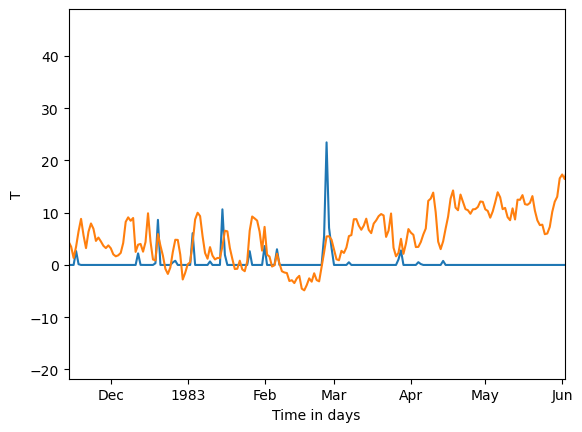

In [35]:
data["M"].plot()
data["T"].plot()
plt.xlim((4700,4900))


In [ ]:
def GetCorr(df):
    # df = pd.DataFrame({
    #     "P": df["P"].cumsum(axis=1),
    #     "T": ds["T"],
    #     "M": ds["M"],
    #     "SF": ds["Q"],
    #     "Q": Q["Q"]
    # })
    return None


In [10]:
def prepareQs(folderloc):
    p = folderloc
    listofdischarges  = []

    for i,e in enumerate(os.scandir(p)):
        if e.is_file():
            with open(e.path, "r") as f:
                print("Reading:", e.name[:7])
                try: 
                    #ds = xr.open_dataset(f"Data/Shapes/grdc_no_{e.name[:7]}.nc")
                    ds = SuperProgram(f"Data/Shapes/grdc_no_{e.name[:7]}.nc")
                except FileNotFoundError:
                    print(e.name[:7], "Has no matching P and T data")
                    continue
                Q = import_Q(e.path, str(i))
                Q = Q.rename(columns={"Date":"time"})
                Q = Q.set_index(["time"])

                df = ds.to_dataframe()
                
                df = pd.concat([df["P"], df["T"], df["M"], df["R"], Q["Q"]], axis=1, join='inner')
                # print(df)
                # df.plot()
            
                df.to_pickle(f"Data/Pickles/{e.name[:7]}.pkl")

                # plt.xlim((1000,1100))
                # plt.legend()
                # print(e.name[:7])
        print(i)
        # if i >10:
        #     break

In [11]:
prepareQs("C:/Users/nunoh/Desktop/THESIS/OriginalData/gaugesRhine")

Reading: 6135035
0
Reading: 6135040
1
Reading: 6135045
6135045 Has no matching P and T data
Reading: 6135055
3
Reading: 6135065
4
Reading: 6135075
5
Reading: 6135100
6
Reading: 6135110
7
Reading: 6135120
8
Reading: 6135200
9
Reading: 6135210
10
Reading: 6135800
11
Reading: 6235100
12
Reading: 6235101
13
Reading: 6235102
14
Reading: 6235110
15
Reading: 6235200
16
Reading: 6235210
17
Reading: 6235300
18
Reading: 6235400
19
Reading: 6235500
20
Reading: 6235530
21
Reading: 6235535
22
Reading: 6335020
23
Reading: 6335030
6335030 Has no matching P and T data
Reading: 6335031
6335031 Has no matching P and T data
Reading: 6335032
6335032 Has no matching P and T data
Reading: 6335035
6335035 Has no matching P and T data
Reading: 6335040
28
Reading: 6335045
6335045 Has no matching P and T data
Reading: 6335046
6335046 Has no matching P and T data
Reading: 6335048
6335048 Has no matching P and T data
Reading: 6335050
32
Reading: 6335055
33
Reading: 6335060
34
Reading: 6335070
35
Reading: 6335075
